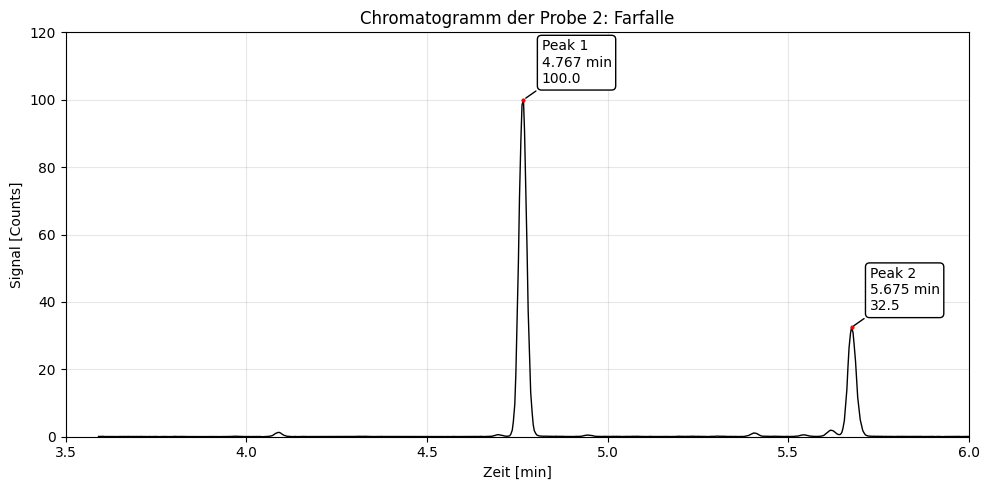

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =========================
# 1) CSV-Datei einlesen
# =========================
df = pd.read_csv(
    "FA_1.csv",
    comment="#",
    sep=",",
    header=None,
    names=["Point", "X", "Y"]
)

# =========================
# 2) Störzeichen entfernen & in Zahlen umwandeln
# =========================
df["X"] = df["X"].astype(str).str.replace(";", "", regex=False)
df["Y"] = df["Y"].astype(str).str.replace(";", "", regex=False)

df["X"] = pd.to_numeric(df["X"], errors="coerce")
df["Y"] = pd.to_numeric(df["Y"], errors="coerce")

df = df.dropna(subset=["X", "Y"])

# =========================
# 3) Peaks finden (nur im Bereich 3.5–6 min)
# =========================
df_plot = df[(df["X"] >= 3.5) & (df["X"] <= 6)]

peaks, _ = find_peaks(df_plot["Y"], prominence=5)

# 4 größte Peaks auswählen
peak_values = df_plot["Y"].iloc[peaks]
top4 = peak_values.nlargest(4).index

# Nach Zeit sortieren
top4_sorted = top4.sort_values(key=lambda x: df_plot["X"].loc[x])

# =========================
# 4) Plot
# =========================
plt.figure(figsize=(10, 5))
plt.plot(df_plot["X"], df_plot["Y"], linewidth=1, color="black")

plt.xlabel("Zeit [min]")
plt.ylabel("Signal [Counts]")
plt.title("Chromatogramm der Probe 2: Farfalle")
plt.grid(True, alpha=0.3)

# =========================
# 5) Peaks markieren + beschriften
# =========================
for i, p in enumerate(top4_sorted, start=1):
    x = df_plot["X"].loc[p]
    y = df_plot["Y"].loc[p]

    # Punkt markieren
    plt.plot(x, y, "ro", markersize=2)

    # Textposition
    text_x = x + 0.05
    text_y = y + df_plot["Y"].max() * 0.05

    # Linie + Text
    plt.annotate(
        f"Peak {i}\n{x:.3f} min\n{y:.1f}",
        xy=(x, y),
        xytext=(text_x, text_y),
        arrowprops=dict(arrowstyle="-", color="black"),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"),
        fontsize=10
    )

# Achsenbegrenzung
plt.xlim(3.5, 6)
plt.ylim(0, df_plot["Y"].max() * 1.2)

plt.tight_layout()
plt.show()


=== Probe 2 farfalla ===
Anzahl Probenmessungen m          = 3
Mittelwert Probensignal ŷ_m       = 0.342950

--- Auf Messlösung bezogen ---
Analysenergebnis [mg/mL]          = 0.248298
± T_x [mg/mL]                     = ± 6.625981e-03

--- Auf das Öl bezogen ---
Analysenergebnis [g/mL]           = 4.138305e-03
± T_x [g/mL]                      = ± 1.104330e-04


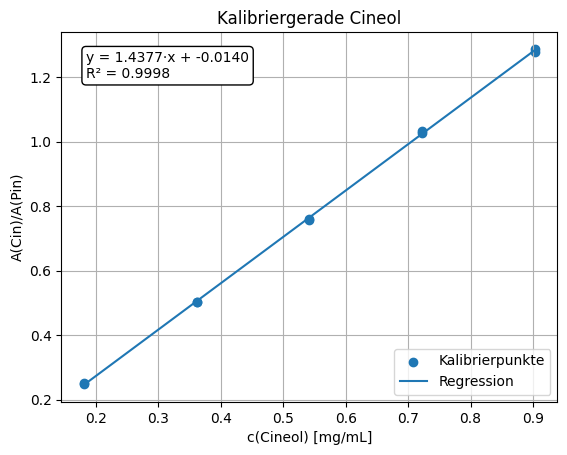

=== Darstellung der Kalibriergerade ===
Steigung b               = 1.437679
Ordinatenabschnitt a     = -0.014023
Bestimmtheitsmaß R²      = 0.9998
Korrelationskoeffizient R= 0.9999
Reststandardabweichung sy= 0.005494
Quadratsumme Qxx         = 0.651854
Anzahl Kalibriermessung n= 10
Freiheitsgrade f         = 8
Mittelwert Kalibriersignal ȳ = 0.764629
t-Wert (einseitig, 95 %) = 1.8595
t-Wert (zweiseitig, 95 %)= 2.3060

=== Nachweis- / Bestimmungsgrenze ===
LOD Messlösung [mg/mL]   = 1.146487e-02
LOQ Messlösung [mg/mL]   = 3.821622e-02
LOD Öl [mg/mL]           = 1.146487e-02  (mit Verdünnungsfaktor = 1.0)
LOQ Öl [mg/mL]           = 3.821622e-02  (mit Verdünnungsfaktor = 1.0)

=== Probe 1 aromance ===
Anzahl Probenmessungen m      = 3
Mittelwert Probensignal ŷ_m   = 0.342950
Mittelwert Kalibriersignal ȳ  = 0.764629
s_x (Messlösung) [mg/mL]      = 2.873360e-03
s_x (Öl) [mg/mL]              = 4.788934e-02  (mit V_ges/V_Probe = 16.666666666666668)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t

# ===============================
# 1) Kalibrierung laden
# ===============================
df = pd.read_excel(
    "Template_GC.xlsx",
    engine="openpyxl",
    usecols="B,F",    # B = c(Cineol), F = A(Cin)/A(Pin)
    skiprows=3,       # ggf. anpassen, falls andere Startzeile
    nrows=12          # Anzahl Kalibrierpunkte (bei dir 10 Messungen)
)

df.columns = ["c", "A_ratio"]   # x und y

x = df["c"].to_numpy()
y = df["A_ratio"].to_numpy()

# ===============================
# 2) Lineare Regression
# ===============================
# y = b * x + a
b, a = np.polyfit(x, y, 1)      # b = Steigung, a = Achsenabschnitt
y_fit = b * x + a

# Korrelationskoeffizient R und R^2
R = np.corrcoef(x, y)[0, 1]
R2 = R**2

# ===============================
# 3) Statistik: sy, Qxx, n, f, t-Werte
# ===============================
n = len(x)               # Anzahl Kalibriermessungen
f = n - 2                # Freiheitsgrade bei einfacher Regression

residuals = y - y_fit
sy = np.sqrt(np.sum(residuals**2) / f)   # Reststandardabweichung

x_mean = np.mean(x)
Qxx = np.sum((x - x_mean)**2)           # Quadratsumme Qxx

y_mean = np.mean(y)                     # Mittelwert Kalibriersignal ȳ

# t-Werte für 95 % (alpha = 0.05)
alpha = 0.05
t_einseitig = t.ppf(1 - alpha, df=f)
t_zweiseitig = t.ppf(1 - alpha/2, df=f)

# ===============================
# 4) LOD / LOQ (auf Messlösung bezogen)
# ===============================
LOD_mess = 3 * sy / abs(b)    # mg/mL
LOQ_mess = 10 * sy / abs(b)   # mg/mL

# Verdünnungsfaktor (falls du auf das Öl umrechnen willst)
D_verduennung = 1.0           # bei dir aktuell 1
LOD_oel = LOD_mess * D_verduennung
LOQ_oel = LOQ_mess * D_verduennung

# ===============================
# 5) Probe 1 aromance: s_x nach deiner Formel
# ===============================
# A(Cin)/A(Pin)-Werte aus deiner Tabelle "Bestimmung der Probe" (Probe 1)
y_probe = np.array([
    0.3427879,
    0.3404430,
    0.3456201,
])

m = len(y_probe)              # Anzahl Probenmessungen
y_m = y_probe.mean()          # Mittelwert Probensignal ŷ_m

# Formel:
# s_x = (s_y / |b|) * sqrt( 1/n + 1/m + ((y_m - y_mean)^2 / (b^2 * Qxx)) )
sx_mess = (sy / abs(b)) * np.sqrt(
    1/n + 1/m + ((y_m - y_mean)**2) / (b**2 * Qxx)
)

# Falls zusätzlich s_x aufs Öl umgerechnet werden soll:
# s_x(Öl) = s_x * V_ges / V_Probe  -> hier nur Platzhalter
V_ges = 1.0      # z.B. 1.0 mL
V_probe = 0.060    # z.B. 0.01 mL = 10 µL, dann hier 0.01 eintragen
f_vol = V_ges / V_probe
sx_oel = sx_mess * f_vol

# ===============================
# 6) Plot der Kalibriergeraden
# ===============================
plt.figure()
plt.scatter(x, y, label="Kalibrierpunkte")
plt.plot(x, y_fit, label="Regression")

plt.xlabel("c(Cineol) [mg/mL]")
plt.ylabel("A(Cin)/A(Pin)")
plt.title("Kalibriergerade Cineol")
plt.grid(True)

plt.text(
    0.05, 0.95,
    f"y = {b:.4f}·x + {a:.4f}\nR² = {R2:.4f}",
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white")
)

# ===============================
# PROBE 2 farfalla – Auswertung für Tabelle
# ===============================

# A(Cin)/A(Pin)-Werte aus deiner Tabelle "Bestimmung der Probe" (Probe 2)
y_probe_2 = np.array([
    0.3427879,
    0.3404430,
    0.3456201,
])

m2 = len(y_probe_2)              # Anzahl Probenmessungen
y_m2 = y_probe_2.mean()          # Mittelwert Probensignal

# Konzentrationen der Messlösung (mg/mL)
# c = (y - a) / b
c_values_2 = (y_probe_2 - a) / b
c_mean_2 = c_values_2.mean()     # Analysenergebnis Messlösung

# Streuung s_x (Messlösung)
sx_mess_2 = (sy / abs(b)) * np.sqrt(
    1/n + 1/m2 + ((y_m2 - y_mean)**2) / (b**2 * Qxx)
)

# Vertrauensbereich T_x (Messlösung)
T_x_mess_2 = sx_mess_2 * t_zweiseitig

# ===============================
# Auf das Öl bezogen
# ===============================
# sx(Öl) = sx * V_ges / V_probe
sx_oel_2 = sx_mess_2 * f_vol

# Analysenergebnis auf das Öl bezogen
c_oel_2 = c_mean_2 * f_vol        # mg/mL
c_oel_2_g = c_oel_2 / 1000        # g/mL

# Vertrauensbereich auf das Öl bezogen
T_x_oel_2 = sx_oel_2 * t_zweiseitig
T_x_oel_2_g = T_x_oel_2 / 1000    # g/mL

# ===============================
# AUSGABE FÜR DEINE EXCEL-TABELLE
# ===============================
print()
print("=== Probe 2 farfalla ===")
print(f"Anzahl Probenmessungen m          = {m2}")
print(f"Mittelwert Probensignal ŷ_m       = {y_m2:.6f}")

print("\n--- Auf Messlösung bezogen ---")
print(f"Analysenergebnis [mg/mL]          = {c_mean_2:.6f}")
print(f"± T_x [mg/mL]                     = ± {T_x_mess_2:.6e}")

print("\n--- Auf das Öl bezogen ---")
print(f"Analysenergebnis [g/mL]           = {c_oel_2_g:.6e}")
print(f"± T_x [g/mL]                      = ± {T_x_oel_2_g:.6e}")

plt.legend()
plt.show()

# ===============================
# 7) Ergebnisse ausgeben (für deine Tabelle)
# ===============================
print("=== Darstellung der Kalibriergerade ===")
print(f"Steigung b               = {b:.6f}")
print(f"Ordinatenabschnitt a     = {a:.6f}")
print(f"Bestimmtheitsmaß R²      = {R2:.4f}")
print(f"Korrelationskoeffizient R= {R:.4f}")
print(f"Reststandardabweichung sy= {sy:.6f}")
print(f"Quadratsumme Qxx         = {Qxx:.6f}")
print(f"Anzahl Kalibriermessung n= {n}")
print(f"Freiheitsgrade f         = {f}")
print(f"Mittelwert Kalibriersignal ȳ = {y_mean:.6f}")
print(f"t-Wert (einseitig, 95 %) = {t_einseitig:.4f}")
print(f"t-Wert (zweiseitig, 95 %)= {t_zweiseitig:.4f}")
print()
print("=== Nachweis- / Bestimmungsgrenze ===")
print(f"LOD Messlösung [mg/mL]   = {LOD_mess:.6e}")
print(f"LOQ Messlösung [mg/mL]   = {LOQ_mess:.6e}")
print(f"LOD Öl [mg/mL]           = {LOD_oel:.6e}  (mit Verdünnungsfaktor = {D_verduennung})")
print(f"LOQ Öl [mg/mL]           = {LOQ_oel:.6e}  (mit Verdünnungsfaktor = {D_verduennung})")
print()
print("=== Probe 1 aromance ===")
print(f"Anzahl Probenmessungen m      = {m}")
print(f"Mittelwert Probensignal ŷ_m   = {y_m:.6f}")
print(f"Mittelwert Kalibriersignal ȳ  = {y_mean:.6f}")
print(f"s_x (Messlösung) [mg/mL]      = {sx_mess:.6e}")
print(f"s_x (Öl) [mg/mL]              = {sx_oel:.6e}  (mit V_ges/V_Probe = {f_vol})")

In [3]:
# ===============================
# PROBE 2 farfalla – Auswertung für Tabelle
# ===============================

# A(Cin)/A(Pin)-Werte aus deiner Tabelle "Bestimmung der Probe" (Probe 2)
y_probe_2 = np.array([
    0.3427879,
    0.3404430,
    0.3456201,
])

m2 = len(y_probe_2)              # Anzahl Probenmessungen
y_m2 = y_probe_2.mean()          # Mittelwert Probensignal

# Konzentrationen der Messlösung (mg/mL)
# c = (y - a) / b
c_values_2 = (y_probe_2 - a) / b
c_mean_2 = c_values_2.mean()     # Analysenergebnis Messlösung

# Streuung s_x (Messlösung)
sx_mess_2 = (sy / abs(b)) * np.sqrt(
    1/n + 1/m2 + ((y_m2 - y_mean)**2) / (b**2 * Qxx)
)

# Vertrauensbereich T_x (Messlösung)
T_x_mess_2 = sx_mess_2 * t_zweiseitig

# ===============================
# Auf das Öl bezogen
# ===============================
# sx(Öl) = sx * V_ges / V_probe
sx_oel_2 = sx_mess_2 * f_vol

# Analysenergebnis auf das Öl bezogen
c_oel_2 = c_mean_2 * f_vol        # mg/mL
c_oel_2_g = c_oel_2 / 1000        # g/mL

# Vertrauensbereich auf das Öl bezogen
T_x_oel_2 = sx_oel_2 * t_zweiseitig
T_x_oel_2_g = T_x_oel_2 / 1000    # g/mL

# ===============================
# AUSGABE FÜR DEINE EXCEL-TABELLE
# ===============================
print()
print("=== Probe 2 farfalla ===")
print(f"Anzahl Probenmessungen m          = {m2}")
print(f"Mittelwert Probensignal ŷ_m       = {y_m2:.6f}")

print("\n--- Auf Messlösung bezogen ---")
print(f"Analysenergebnis [mg/mL]          = {c_mean_2:.6f}")
print(f"± T_x [mg/mL]                     = ± {T_x_mess_2:.6e}")

print("\n--- Auf das Öl bezogen ---")
print(f"Analysenergebnis [g/mL]           = {c_oel_2_g:.6e}")
print(f"± T_x [g/mL]                      = ± {T_x_oel_2_g:.6e}")


=== Probe 2 farfalla ===
Anzahl Probenmessungen m          = 3
Mittelwert Probensignal ŷ_m       = 0.342950

--- Auf Messlösung bezogen ---
Analysenergebnis [mg/mL]          = 0.248298
± T_x [mg/mL]                     = ± 6.625981e-03

--- Auf das Öl bezogen ---
Analysenergebnis [g/mL]           = 4.138305e-03
± T_x [g/mL]                      = ± 1.104330e-04
